# Predicting Movie Revenue From Movie Budget

**Authors:** Audrey Vo, Roxanna Ng, Nikita Prabhu, Philip Chen

## Summary

## Introduction

### Background

### Research Question

How does movie budget predict movie revenue? 

### The Data Set

In [1]:
library(fivethirtyeight)
library(dplyr)
library(ggplot2)
library(tidymodels)

Some larger datasets need to be installed separately, like senators and
house_district_forecast. To install these, we recommend you install the
fivethirtyeightdata package by running:
install.packages('fivethirtyeightdata', repos =
'https://fivethirtyeightdata.github.io/drat/', type = 'source')


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching packages ────────────────────────────────────── tidymodels 1.4.1 ──

✔ broom        1.0.11     ✔ rsample      1.3.1 
✔ dials        1.4.2      ✔ tailor       0.1.0 
✔ infer        1.1.0      ✔ tidyr        1.3.2 
✔ modeldata    1.5.1      ✔ tune         2.0.1 
✔ parsnip      1.4.0      ✔ workflows    1.3.0 
✔ purrr        1.2.0      ✔ workflowsets 1.1.1 
✔ recipes      1.3.1      ✔ yardstick    1.3.2 

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ 

### Loading in Data

In [2]:
data("bechdel", package = "fivethirtyeight")
write.csv(bechdel, "data/raw/raw_bechdel.csv", row.names = FALSE)

### Cleaning Data

In [3]:
movie_data <- bechdel[, c("budget", "domgross")]
head(movie_data)

budget,domgross
<int>,<dbl>
13000000,25682380
45000000,13414714
20000000,53107035
61000000,75612460
40000000,95020213
225000000,38362475


In [4]:
print(paste("# of null values (before filtering):", sum(is.na(movie_data))))

movie_data <- movie_data %>%
  filter(!is.na(budget), !is.na(domgross))

print(paste("# of null values (after filtering):", sum(is.na(movie_data))))

[1] "# of null values (before filtering): 17"
[1] "# of null values (after filtering): 0"


In [5]:
print(sum(movie_data$budget == 0))
print(sum(movie_data$domgross == 0))

[1] 0
[1] 1


In [6]:
movie_data[movie_data$domgross == 0, ]

movie_data <- movie_data %>%
  filter(budget > 0, domgross > 0)

print(sum(movie_data$budget == 0))
print(sum(movie_data$domgross == 0))

budget,domgross
<int>,<dbl>
18000000,0


[1] 0
[1] 0


## EDA

In [7]:
summary(movie_data)

     budget             domgross        
 Min.   :     7000   Min.   :      828  
 1st Qu.: 12000000   1st Qu.: 16320870  
 Median : 30000000   Median : 42239614  
 Mean   : 45174408   Mean   : 69170974  
 3rd Qu.: 60000000   3rd Qu.: 93382814  
 Max.   :425000000   Max.   :760507625  

In [8]:
str(movie_data)

tibble [1,776 × 2] (S3: tbl_df/tbl/data.frame)
 $ budget  : int [1:1776] 13000000 45000000 20000000 61000000 40000000 225000000 92000000 12000000 13000000 130000000 ...
 $ domgross: num [1:1776] 25682380 13414714 53107035 75612460 95020213 ...


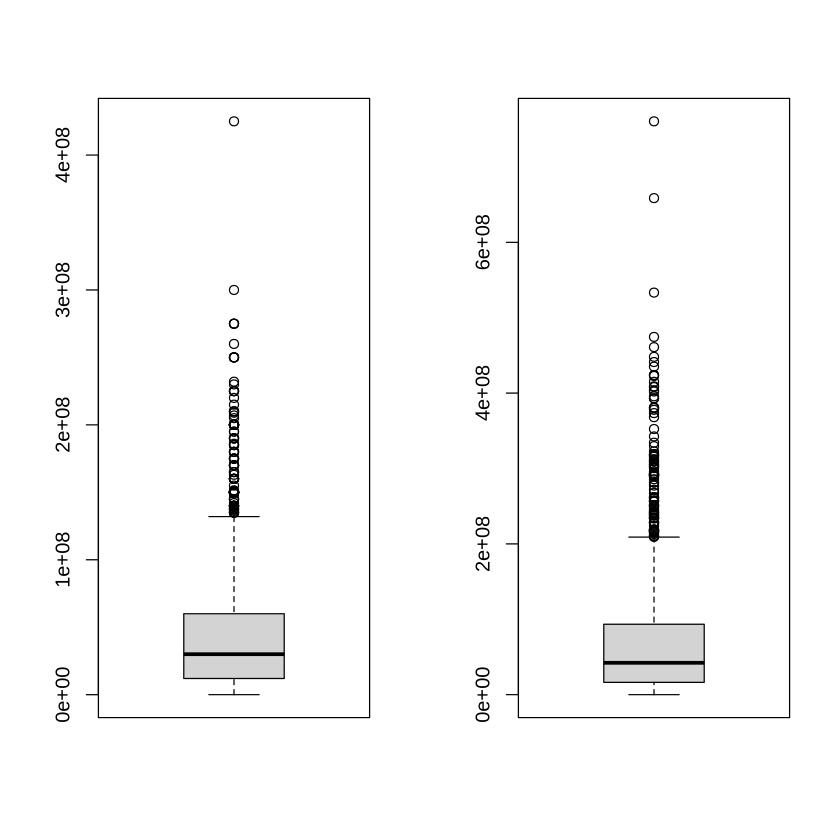

In [67]:
par(mfrow = c(1, 2))
boxplot(movie_data$budget)
boxplot(movie_data$domgross)
par(mfrow = c(1,1))

**Figure 1(left):** Boxplot of movie budget \
**Figure 1(right):** Boxplot of movie revenue

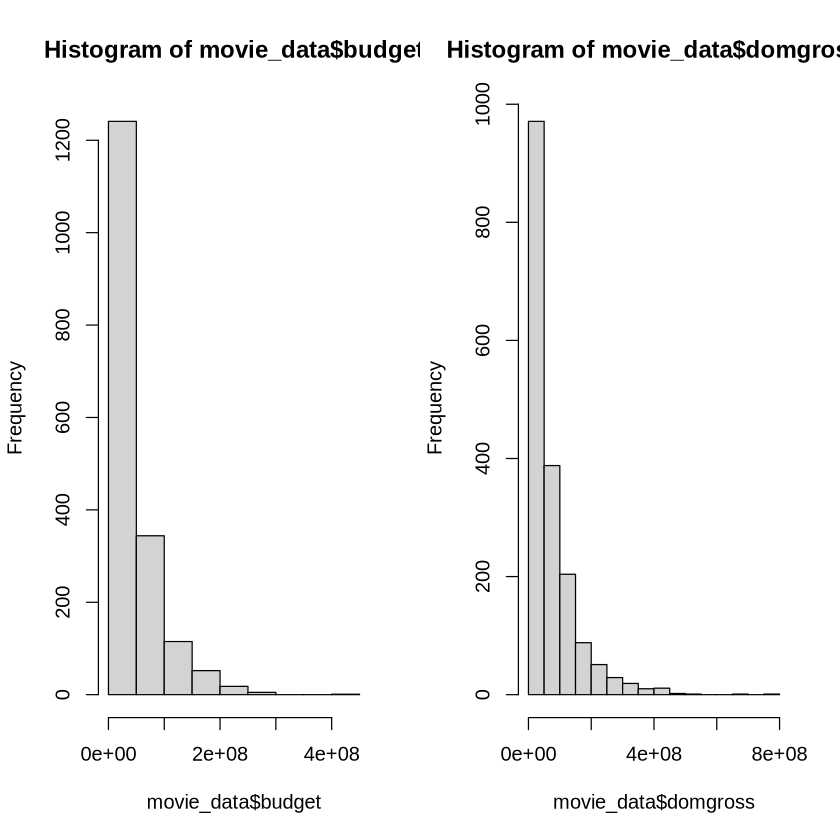

In [69]:
par(mfrow = c(1, 2))
hist(movie_data$budget)
hist(movie_data$domgross)
par(mfrow = c(1,1))

**Figure 2(left):** Histogram of movie budget \
**Figure 2(left):** Histogram of movie revenue

`geom_smooth()` using formula = 'y ~ x'


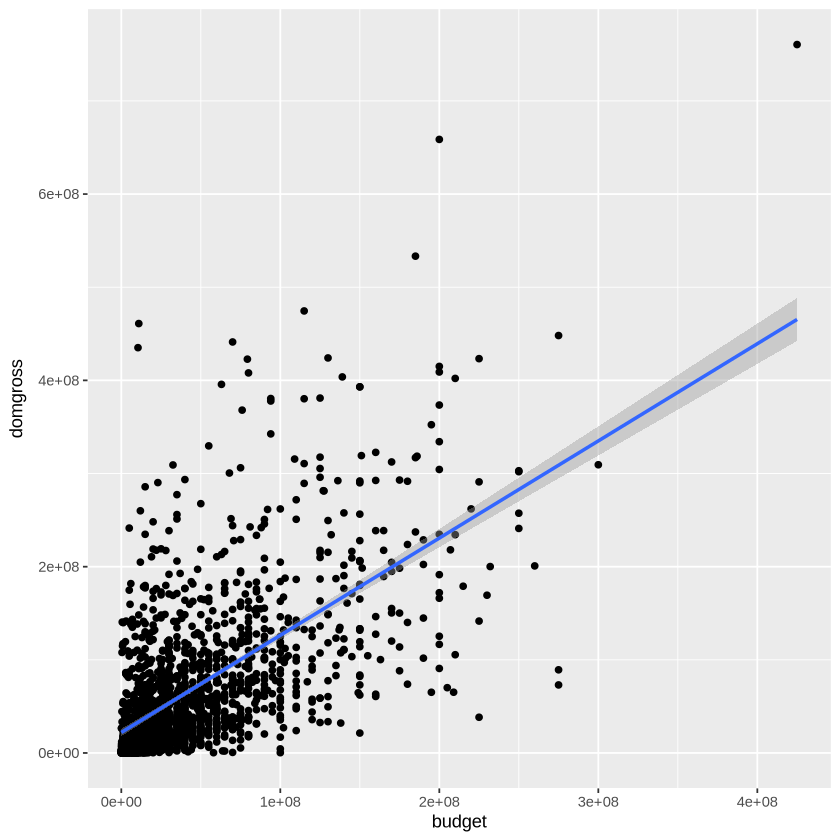

In [11]:
budget_rev_plot <- ggplot(movie_data, aes(x = budget, y = domgross)) +
  geom_point() +
  geom_smooth(method = "lm")
budget_rev_plot

**Figure 3 :** Scatterplot of Domestic Revenue vs Movie Budget

There appears to be heteroscedasticity, since variance increases with budget.

In [12]:
cor(movie_data$budget, movie_data$domgross)

[1] 0.6268848

`geom_smooth()` using formula = 'y ~ x'


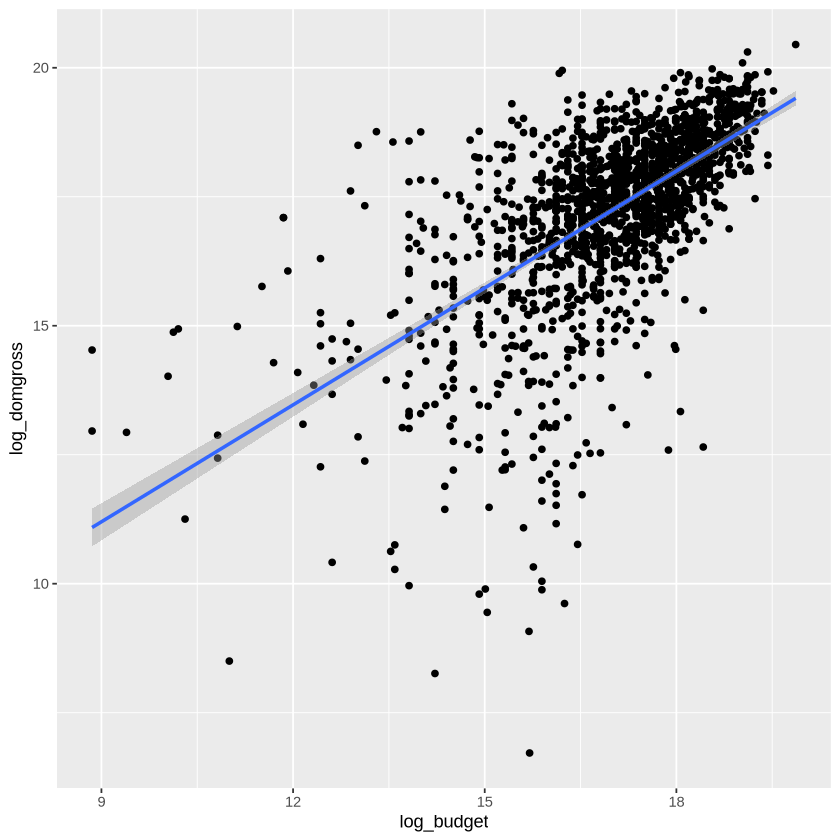

In [13]:
movie_data <- movie_data %>% 
  mutate(log_budget = log(budget), log_domgross = log(domgross))

log_budget_rev_plot <- ggplot(movie_data, aes(x = log_budget, y = log_domgross)) +
  geom_point() +
  geom_smooth(method = "lm")
log_budget_rev_plot

**Figure 4 :** Scatterplot of log(Domestic Revenue) vs log(Movie Budget)

In [14]:
head(movie_data)
write.csv(movie_data, "data/processed/clean_bechdel.csv", row.names = FALSE)

budget,domgross,log_budget,log_domgross
<int>,<dbl>,<dbl>,<dbl>
13000000,25682380,16.38046,17.06132
45000000,13414714,17.62217,16.41186
20000000,53107035,16.81124,17.78782
61000000,75612460,17.92638,18.14113
40000000,95020213,17.50439,18.36960
225000000,38362475,19.23161,17.46259


## Methods and Results

Due to the relationship between movie budget and movie revenue being relatively linear, we will use a linear regression for analysis. Below, we split the data and summarize the number of observations in each training and test split. We also look at the mean values for the log-transformed budget and revenue columns in each training and test split. 

In [15]:
data_split <- initial_split(movie_data, prop = 0.7)
train <- training(data_split)
test <- testing(data_split) 

train_n <- train |> summarize(n = n()) |> pull()
print(paste("Training data row count: ", train_n))
test_n <- test |> summarize(n = n()) |> pull()
print(paste("Test data row count: ", test_n))

train_mean <- train |> summarize(train_log_budget_mean = mean(log_budget),
                                 train_log_domgross_mean = mean(log_domgross))
train_mean
test_mean <- test |> summarize(test_log_budget_mean = mean(log_budget),
                                 test_log_domgross_mean = mean(log_domgross))
test_mean

[1] "Training data row count:  1243"
[1] "Test data row count:  533"


train_log_budget_mean,train_log_domgross_mean
<dbl>,<dbl>
17.00021,17.27526


test_log_budget_mean,test_log_domgross_mean
<dbl>,<dbl>
16.88549,17.08141


Below we fit a simple linear regression with the log-transformed versions of movie budget and movie revenue to account for data skew. The predictor (log-transformed movie budget) is statistically significant. 

In [16]:
lm <- lm(formula = log_domgross ~ log_budget, data = train)
summary(lm)


Call:
lm(formula = log_domgross ~ log_budget, data = train)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.2181 -0.5611  0.1673  0.7239  4.2594 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  4.51563    0.45657    9.89   <2e-16 ***
log_budget   0.75056    0.02676   28.04   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.339 on 1241 degrees of freedom
Multiple R-squared:  0.3879,	Adjusted R-squared:  0.3874 
F-statistic: 786.5 on 1 and 1241 DF,  p-value: < 2.2e-16


Using the fitted model above, we predict on the test set. 

In [17]:
preds <- predict(lm, test) |> bind_cols(test) 
preds <- preds |> rename(log_domgross_preds = ...1) |> select(log_domgross_preds, log_budget, log_domgross)
head(preds)

New names:
• `` -> `...1`


log_domgross_preds,log_budget,log_domgross
<dbl>,<dbl>,<dbl>
17.82115,17.72753,16.78347
17.43775,17.21671,17.37845
18.41294,18.51599,17.93840
18.07370,18.06401,17.04287
17.01145,16.64872,17.80893
18.69417,18.89068,19.29063


`geom_smooth()` using formula = 'y ~ x'


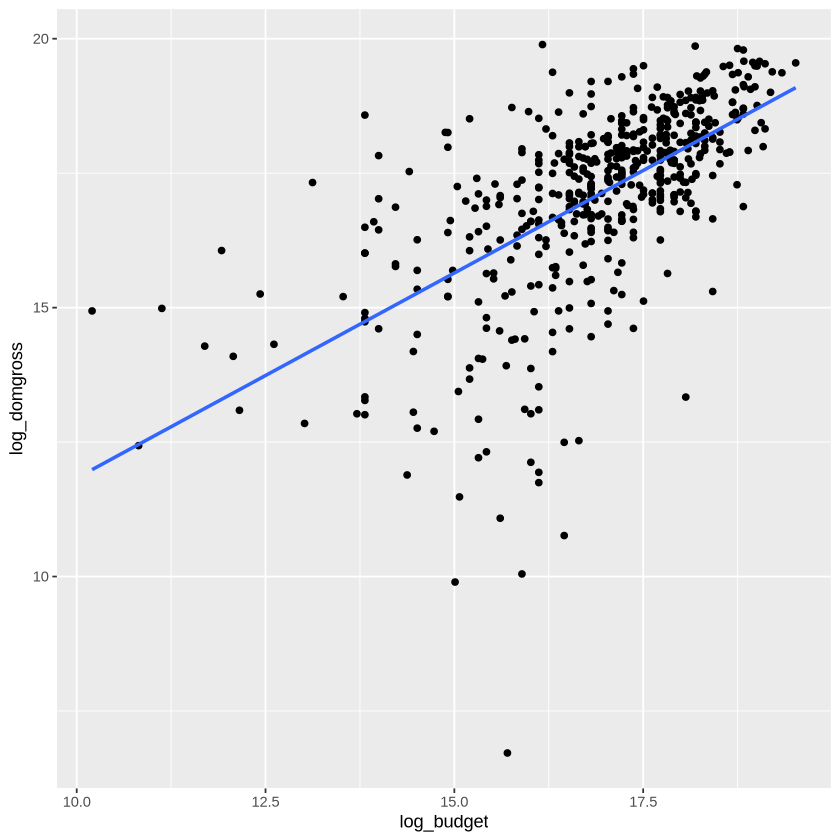

In [18]:
preds_plot <- preds |>
    ggplot(aes(x = log_budget, y = log_domgross)) +
    geom_point() +
    geom_smooth(method = "lm", se = FALSE)
preds_plot

**Figure 5 :** Scatterplot of log(movie budget) vs log(domestic revenue) for the test set

In [59]:
metrics <- metrics(preds, truth = log_domgross, estimate = log_domgross_preds)|>
filter(.metric=='rmse')
metrics

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1.39324


In [61]:
exp(metrics$.estimate)

[1] 4.027879

The RMPSE is 1.39. This means on average, the model’s predicted log revenue differs from the actual log revenue by about 1.39 log. On average, the predicted revenue can be roughly 4.03 times higher or lower than the actual revenue.

### Knn Regression model

In [39]:
knn_recipe <- recipe(log_domgross ~ log_budget, data = train) |>
  step_scale(all_predictors()) |>
  step_center(all_predictors())

knn_spec <- nearest_neighbor(weight_func = "rectangular",
                              neighbors = tune()) |>
  set_engine("kknn") |>
  set_mode("regression")

knn_vfold <- vfold_cv(train, v = 10, strata = log_domgross)

knn_wkflw <- workflow() |>
  add_recipe(knn_recipe) |>
  add_model(knn_spec)

In [40]:
set.seed(120)
gridvals <- tibble(neighbors = seq(from = 1, to = 200, by = 3))

knn_results <- knn_wkflw |>
  tune_grid(resamples = knn_vfold, grid = gridvals) |>
  collect_metrics() |>
  filter(.metric == "rmse")

head(knn_results)

neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
1,rmse,standard,1.737524,10,0.08386887,pre0_mod01_post0
4,rmse,standard,1.446587,10,0.05720511,pre0_mod02_post0
7,rmse,standard,1.382359,10,0.05792272,pre0_mod03_post0
10,rmse,standard,1.376040,10,0.05229723,pre0_mod04_post0
13,rmse,standard,1.358601,10,0.05627091,pre0_mod05_post0
16,rmse,standard,1.344883,10,0.05490144,pre0_mod06_post0


In [41]:
knn_min <- knn_results |>
  filter(mean == min(mean))

knn_min

neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
88,rmse,standard,1.323689,10,0.06319125,pre0_mod30_post0


The minimum RSMPE is at K=88

In [48]:
kmin <- knn_min |> pull(neighbors)

knn_spec_min <- nearest_neighbor(weight_func = "rectangular", neighbors = kmin) |>
  set_engine("kknn") |>
  set_mode("regression")

cv_metrics <- workflow() |>
  add_recipe(knn_recipe) |>
  add_model(knn_spec_min) |>
   fit_resamples(resamples = knn_vfold)|>
   collect_metrics() |>
   filter(.metric == 'rmse')
cv_metrics

.metric,.estimator,mean,n,std_err,.config
<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
rmse,standard,1.323689,10,0.06319125,pre0_mod0_post0


For the training set, the average RMSE across the 10 folds is 1.324 log-dollars with a standard error of 0.063

In [49]:
knn_fit_min <- workflow() |>
  add_recipe(knn_recipe) |>
  add_model(knn_spec_min) |>
  fit(data = train)

knn_summary <- knn_fit_min |>
  predict(test) |>
  bind_cols(test) |>
  metrics(truth = log_domgross, estimate = .pred) |>
  filter(.metric == 'rmse')

knn_summary

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
rmse,standard,1.372257


In [62]:
exp(knn_summary$.estimate)

[1] 3.944241

The test RMSE of 1.372 means that, on average, the KNN model’s predicted log revenue differs from the actual log revenue by about 1.37. On average, the predicted revenue can be roughly 3.94 times higher or lower than the actual revenue.

So, both KNN and linear regression have similar predictive accuracy, with KNN being slightly better.

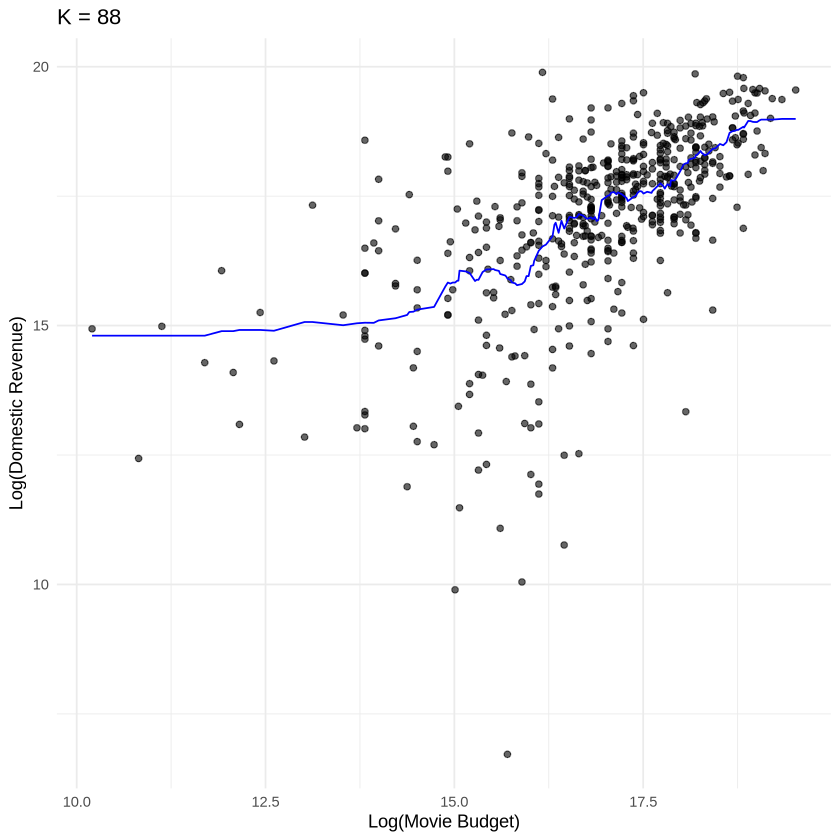

In [56]:
knn_preds <- knn_fit_min |>
  predict(test) |>
  bind_cols(test) |>
  rename(log_domgross_pred = .pred)

ggplot(knn_preds, aes(x = log_budget, y = log_domgross)) +
  geom_point(alpha = 0.6) +                                
  geom_line(aes(y = log_domgross_pred), color = "blue") +
  labs(
    title = "KNN Regression: Predicted vs Actual",
    x = "Log(Movie Budget)",
    y = "Log(Domestic Revenue)"
  ) + ggtitle(paste0("K = ", kmin)) +
  theme_minimal()

**Figure 6 :** Predicted values of log(movie revenue) (blue line) for the final K-NN regression model